# Free-Lunch 🍽️
### "Safe stocks beat risky ones" — so where's the catch?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free lunch?: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

One of finance's favourite anomalies: low-risk (low-beta) assets earn more *per unit of risk* than high-risk ones. The strategy that harvests it — betting against beta — has a famous Sharpe. The catch hides in one word: **leverage**. To make the safe-stock bet market-sized you have to borrow ~3× your capital, and once the borrowing is priced honestly — every dollar charged or credited exactly once — the famous edge trails the market it claims to beat.

> 📓 **Plain-language layer.** The financing ledger, the sweep and the bond-bull confound are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (free_lunch/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from free_lunch import data, strategy as st
from quantlab import repro
assets, market, rf_ann = data.fetch_etf_panel()  # cache-first; built by examples/verify.py --fetch
cut = pd.Timestamp(repro.DEFAULT_AS_OF)          # pin: complete months strictly before the desk as-of
assets, market, rf_ann = assets[assets.index < cut], market[market.index < cut], rf_ann[rf_ann.index < cut]
rf_m = data.monthly_rf(rf_ann)
gross, lev = st.bab_returns(assets, market, rf_m, return_leverage=True)
mkt = st.market_monthly(market).loc[gross.index]
rf = rf_m.reindex(gross.index).fillna(0.0)       # the cash hurdle every Sharpe is measured against


## The answer first 🎯

| The pitch | The catch |
|---|---|
| "Low-beta beats high-beta risk-adjusted" | Priced like-for-like (everything excess of the T-bill), the book's gross Sharpe (0.32) is **below** just owning the market (0.48). |
| "A market-neutral free lunch" | It runs the safe leg at **2.8×** — borrowed money, billed at T-bill *plus* a spread. |
| "Great Sharpe, and it used to be even better!" | The great early years were mostly a **levered bond trade** — the 'low-beta half' of this panel is Treasuries and gold. |

## 1 · The claim

Betting against beta (Frazzini & Pedersen 2014): leverage-constrained investors overpay for high-beta assets, so you can earn a premium by going **long low-beta (levered up to beta 1)** and **short high-beta**. Market-neutral, positive expected return.

## 2 · So what?

If true and tradable, it's a low-risk way to beat the market — the holy grail. But "levered up to beta 1" is doing enormous work in that sentence. We make the leverage explicit and price it.

## 3 · How would we even know?

Build the beta-neutral book on a liquid-ETF cross-section with a real cash rate (the 13-week T-bill): the borrowed slice pays T-bill + spread, the short's proceeds earn T-bill − fee, and **every Sharpe — book and market alike — is measured over the same T-bill**, so the race is fair. Then sweep the financing spread and watch the edge.

In [2]:
print(f'Average leverage on the low-beta (long) leg: {lev:.2f}x   (avg T-bill {rf.mean()*12:.1%}/yr)')
rows={'BAB gross (self-financed)':st.summary(gross+rf,rf=rf),'SPY (market)':st.summary(mkt,rf=rf)}
display(pd.DataFrame(rows).T[['cagr','sharpe','vol_ann','max_drawdown']].round(3))

Average leverage on the low-beta (long) leg: 2.77x   (avg T-bill 1.9%/yr)


,cagr,sharpe,vol_ann,max_drawdown
BAB gross (self-financed),0.066,0.318,0.216,-0.475
SPY (market),0.083,0.476,0.152,-0.508


**Already, before any friction:** the safe-stock book earns a *lower* Sharpe than simply owning the market, once both are measured against the same cash hurdle. The old pitch compared a long-short return that quietly enjoyed free funding to a market return that didn't — that's where the apparent near-tie came from.

## 4 · The teardown — price the leverage

Now charge a realistic *spread* over the T-bill on the borrowed 1.8× and watch what's left dissolve.

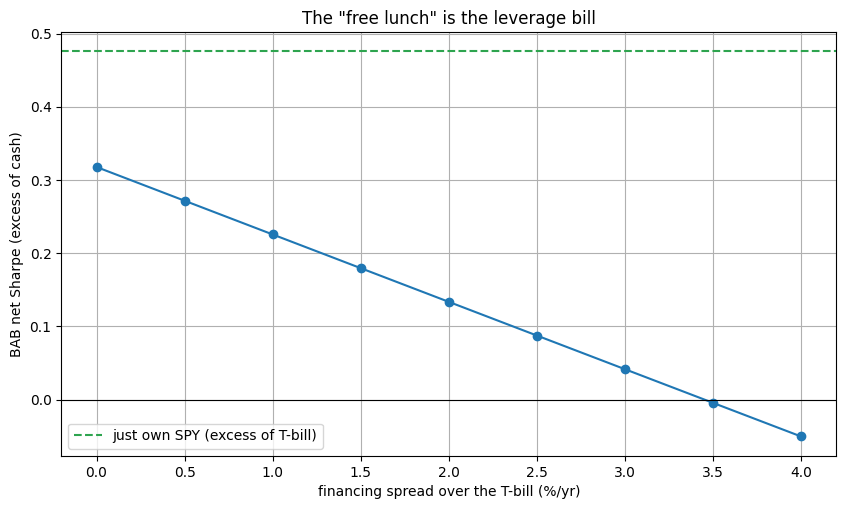

In [3]:
spreads=np.linspace(0,0.04,9)
shp=[st.summary(st.bab_returns(assets,market,rf_m,financing_spread_ann=s,borrow_fee_ann=s/4))['sharpe'] for s in spreads]
fig,ax=plt.subplots()
ax.plot(spreads*100, shp, marker='o')
ax.axhline(st.summary(mkt,rf=rf)['sharpe'],color='#2ea44f',ls='--',label='just own SPY (excess of T-bill)')
ax.axhline(0,color='k',lw=.8)
ax.set_xlabel('financing spread over the T-bill (%/yr)'); ax.set_ylabel('BAB net Sharpe (excess of cash)')
ax.set_title('The "free lunch" is the leverage bill'); ax.legend(); plt.show()

**Read it plainly.** At a zero spread the line already starts below "just own SPY" — and every realistic borrow cost drags it lower, through zero around 3.5%. The premium was rent on leverage. (Same lesson as [Study 30 House-Edge](../../30-house-edge/).)

## 5 · The verdict

**Signal: Weak** — the tilt exists but doesn't beat the market gross. **Tradability: Mirage** — financing erases it. **Free lunch?: Busted** — you pay for it in borrow, and the best years were mostly a bond-bull trade (the quants notebook shows the receipts).

## 6 · Could you actually trade it?

Only if you can borrow ~1.8× of your capital at the T-bill flat, indefinitely — which retail can't, and which is precisely the constraint the anomaly claims to exploit in *others*. Charge yourself a real spread and the edge is gone.

## 7 · Going further 🚪

The quants notebook shows the 2.77× construction, the ledger, and why the apparent decay was duration in disguise. Next: [Study 44 Growth-Spurt](../../44-growth-spurt/) — the asset-growth anomaly, the highest headline Sharpe on the vendor's list, on real balance-sheet data.